## Total Fuel Evaluation (Sum of Phase Models)

In this section, we evaluate total fuel consumption by combining the phase-level ML predictions.

Steps:
1. Load the November–December test flights from the feature table and obtain the ground-truth total fuel (`total_fuel_modeled`).  
   If a total column is not available, we compute it by summing the phase fuel columns.
2. Load phase prediction files (takeoff, climb, cruise, descent, landing) exported earlier as CSV.
3. Merge predictions by `flight_id` and set missing phase predictions to 0 (phase not present or not predicted).
4. Compute total predicted fuel as the sum of predicted phase fuels.
5. Merge predictions with ground truth and report overall error metrics (MAE and MAPE).
6. Print average predicted fuel per phase and inspect the largest absolute errors for debugging.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DB_PATH = "../opensky.sqlite"
FEATURE_TABLE = "flight_phase_features_v2"
YEAR = 2022

def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)
    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return 100*np.mean(np.abs((y_true - y_pred)/np.clip(np.abs(y_true),1e-6,None)))

# --- load test truth ---
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11,12])].copy()

true_total_col = "total_fuel_modeled"
if true_total_col not in test.columns:
    phase_cols = ["takeoff_fuel","climb_fuel","cruise_fuel","descent_fuel","landing_fuel"]
    test["true_total"] = test[phase_cols].sum(axis=1)
    true_total_col = "true_total"

truth = test[["flight_id", true_total_col]].rename(columns={true_total_col:"true_total"})

csv_dir = ("csv_files")
for fname in (
    "pred_takeoff.csv",
    "pred_climb.csv",
    "pred_cruise.csv",
    "pred_descent.csv",
    "pred_landing.csv",
):
    full = os.path.join(csv_dir, fname)
    if not os.path.exists(full):
        raise FileNotFoundError(f"prediction file not found: {full}")

p_takeoff = pd.read_csv(os.path.join(csv_dir, "pred_takeoff.csv"))
p_climb   = pd.read_csv(os.path.join(csv_dir, "pred_climb.csv"))
p_cruise  = pd.read_csv(os.path.join(csv_dir, "pred_cruise.csv"))
p_descent = pd.read_csv(os.path.join(csv_dir, "pred_descent.csv"))
p_landing = pd.read_csv(os.path.join(csv_dir, "pred_landing.csv"))

pred_all = (p_takeoff
    .merge(p_climb, on="flight_id", how="outer")
    .merge(p_cruise, on="flight_id", how="outer")
    .merge(p_descent, on="flight_id", how="outer")
    .merge(p_landing, on="flight_id", how="outer")
)

for c in ["pred_takeoff","pred_climb","pred_cruise","pred_descent","pred_landing"]:
    pred_all[c] = pred_all[c].fillna(0.0)

pred_all["pred_total"] = pred_all[["pred_takeoff","pred_climb","pred_cruise","pred_descent","pred_landing"]].sum(axis=1)

# merge truth
pred_all = pred_all.merge(truth, on="flight_id", how="left")

mask = pred_all["true_total"].notna() & np.isfinite(pred_all["true_total"])
y_true = pred_all.loc[mask, "true_total"].to_numpy(float)
y_pred = pred_all.loc[mask, "pred_total"].to_numpy(float)

print("TOTAL RESULTS (sum of phase ML)")
print("N:", int(mask.sum()))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MAPE:", mape(y_true, y_pred))
print(f"MSE : {mean_squared_error(y_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"R²  : {r2_score(y_true, y_pred):.4f}")



print(pred_all[[
    "pred_takeoff",
    "pred_climb",
    "pred_cruise",
    "pred_descent",
    "pred_landing"
]].mean())

pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)

TOTAL RESULTS (sum of phase ML)
N: 3505
MAE: 74.20205702772449
MAPE: 4.4036862446802125
MSE : 9997.3043
RMSE: 99.9865
R²  : 0.9630
pred_takeoff      47.604402
pred_climb      1075.903193
pred_cruise      261.944031
pred_descent     322.346639
pred_landing       7.307822
dtype: float64


,flight_id,pred_takeoff,pred_climb,pred_cruise,pred_descent,pred_landing,pred_total,true_total,abs_err
2072,479ee7-NOZ50A-12-29-17-57,0.000000,1588.85060,1041.794122,328.02393,7.534778,2966.203429,4099.73,1133.526571
1235,479227-NOZ602-12-13-08-23,58.142600,1084.98060,680.488665,462.90054,7.772590,2294.284995,3223.76,929.475005
2380,47a0bf-NOZ4RZ-12-23-07-39,0.000000,1583.41490,1390.455836,576.70026,9.228454,3559.799450,4204.72,644.920550
210,478742-NOZ628-12-21-17-45,53.792927,1134.37150,67.937763,324.13740,7.613509,1587.853098,2224.98,637.126902
1515,4792db-NOZ145-12-01-16-01,53.847940,436.46730,0.000000,260.24664,7.928434,758.490314,1273.72,515.229686
2707,47a218-NOZ56U-12-04-20-01,62.300440,1482.89300,1043.761817,548.76180,7.801253,3145.518310,3659.06,513.541690
294,47875c-NOZ143-12-18-15-15,49.283070,449.84515,0.000000,260.04060,7.816497,766.985317,1253.53,486.544683
2337,47a097-NOZ541-12-29-16-04,0.000000,1215.93440,287.783647,689.64905,7.172433,2200.539530,2649.24,448.700470
2837,47a31a-NOZ133-11-22-14-52,42.367348,342.51490,0.000000,217.41693,7.151045,609.450223,1021.04,411.589777
1317,4792a6-NOZ522-12-08-06-12,53.413910,1080.49260,133.497805,394.01950,7.209174,1668.632989,2080.11,411.477011


# Plot estimated vs actual total fuel

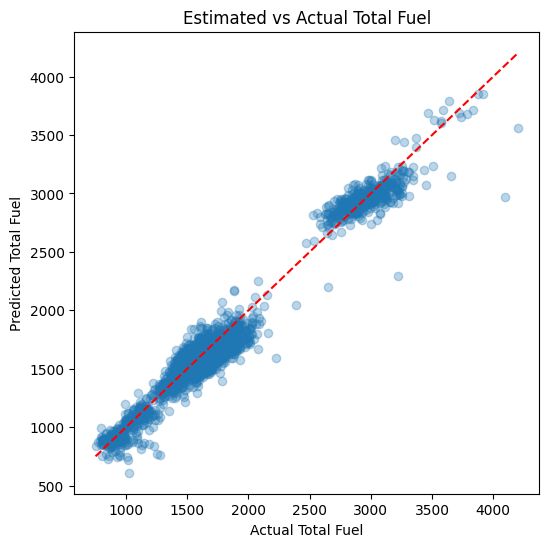

                      flight_id
2072  479ee7-NOZ50A-12-29-17-57
1235  479227-NOZ602-12-13-08-23
2380  47a0bf-NOZ4RZ-12-23-07-39
210   478742-NOZ628-12-21-17-45
1515  4792db-NOZ145-12-01-16-01
2707  47a218-NOZ56U-12-04-20-01
294   47875c-NOZ143-12-18-15-15
2337  47a097-NOZ541-12-29-16-04
2837  47a31a-NOZ133-11-22-14-52
1317  4792a6-NOZ522-12-08-06-12
899   4787b3-NOZ648-11-27-21-37
2362  47a0bf-NOZ133-12-02-14-57
1311  4792a6-NOZ347-12-30-17-50
721   4787a0-NOZ182-12-17-08-30
2407  47a0bf-NOZ536-11-18-14-32
94    478741-NOZ543-12-16-18-03
1003  4791dd-NOZ1BG-11-24-06-09
1177  479227-NOZ133-11-21-14-52
2840  47a31a-NOZ133-11-28-14-57
275   47875a-NOZ628-11-23-18-02


In [2]:

plt.figure(figsize=(6,6))
plt.scatter(
    pred_all["true_total"],
    pred_all["pred_total"],
    alpha=0.3
)

min_val = pred_all["true_total"].min()
max_val = pred_all["true_total"].max()

plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Predicted Total Fuel")
plt.title("Estimated vs Actual Total Fuel")
plt.show()


pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)


pred_all["rel_err_pct"] = 100 * (
    (pred_all["pred_total"] - pred_all["true_total"])
    / pred_all["true_total"]
)

#print(pred_all["rel_err_pct"].describe())


outliers = pred_all.sort_values("abs_err", ascending=False).head(20)

cols = [
    "flight_id",
]

print(outliers[cols])

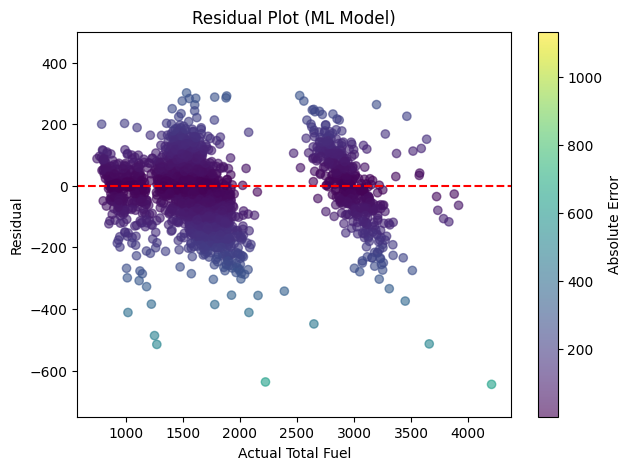

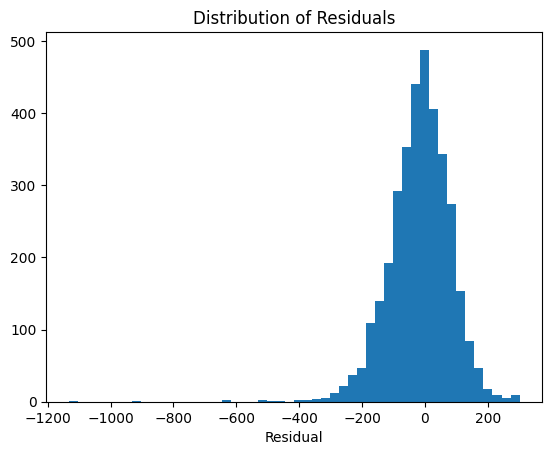

In [3]:
# compute residual (prediction - truth) if not already computed
if "residual" not in pred_all.columns:
    pred_all["residual"] = pred_all["pred_total"] - pred_all["true_total"]

plt.figure(figsize=(7,5))

plt.ylim(-750, 500)

plt.scatter(
    pred_all["true_total"],
    pred_all["residual"],
    c=pred_all["abs_err"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Absolute Error")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Residual")
plt.title("Residual Plot (ML Model)")

plt.show()

plt.hist(pred_all["residual"], bins=50)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

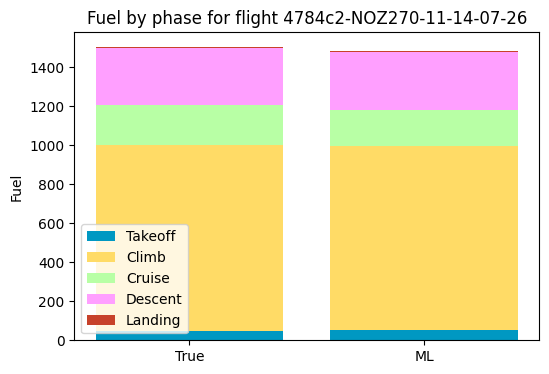

In [4]:
phases_true = [
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]

phases_pred = [
    "pred_takeoff",
    "pred_climb",
    "pred_cruise",
    "pred_descent",
    "pred_landing"
]

colors = {
    "takeoff_fuel": "#0098c2",
    "climb_fuel": "#ffdb66",
    "cruise_fuel": "#b8ffa5",
    "descent_fuel": "#ff9fff",
    "landing_fuel": "#c7422b"
}


phase_truth = test[[
    "flight_id",
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]].drop_duplicates("flight_id")

pred_all = pred_all.merge(phase_truth, on="flight_id", how="left")

row = pred_all.iloc[3]

fig, ax = plt.subplots(figsize=(6,4))

bottom_true = 0
bottom_pred = 0

for true_col, pred_col in zip(phases_true, phases_pred):

    ax.bar(
        "True",
        row[true_col],
        bottom=bottom_true,
        color=colors[true_col],
        label=true_col.replace("_fuel","").capitalize()
    )

    ax.bar(
        "ML",
        row[pred_col],
        bottom=bottom_pred,
        color=colors[true_col]
    )

    bottom_true += row[true_col]
    bottom_pred += row[pred_col]

ax.set_ylabel("Fuel")
ax.set_title(f"Fuel by phase for flight {row['flight_id']}")

ax.legend()

plt.show()

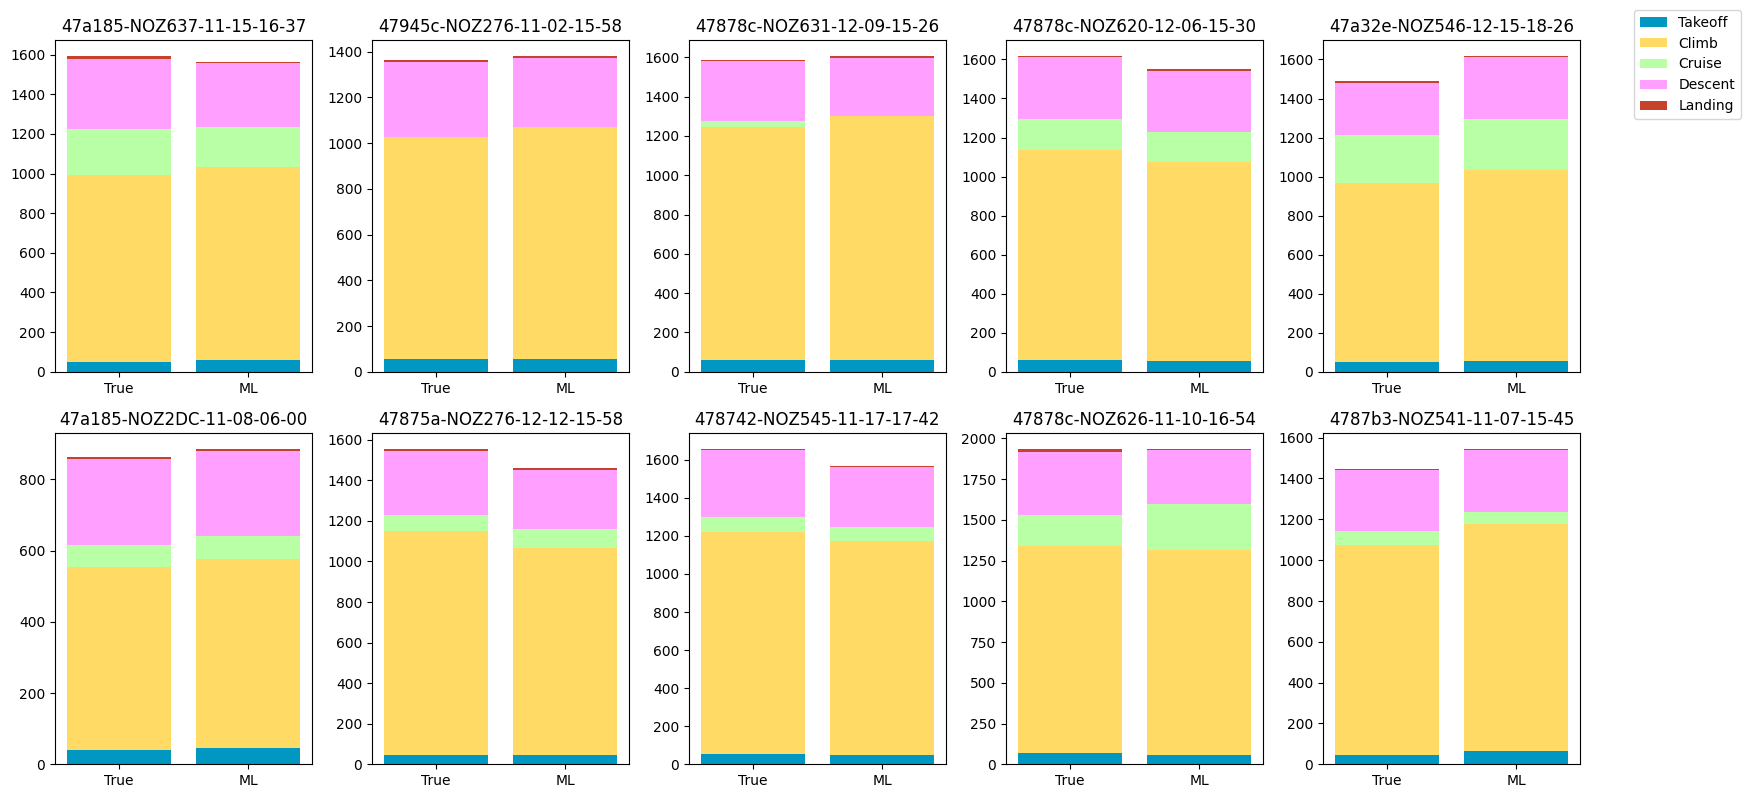

In [12]:
n = 10
sample = pred_all.sample(n, random_state=9)

cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16,4*rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):

    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col in zip(phases_true, phases_pred):

        label = true_col.replace("_fuel","").capitalize()

        ax.bar(
            "True",
            row[true_col],
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "ML",
            row[pred_col],
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_title(row["flight_id"])
    ax.set_xticks([0,1])
    ax.set_xticklabels(["True","ML"])

# fjern tomme plots
for ax in axes[n:]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()